# Sustainable PEFT Benchmark — Real Measurement Pipeline (v2)

**Platform: run this on Kaggle** (Notebook → Settings → Accelerator = **GPU T4 x2**, Internet = **ON**).
Colab Free also works but sessions die and the disk is wiped; see the last cell for notes.

## What this notebook does
1. Installs libraries and detects the GPU
2. Writes config files (backbones / tasks / PEFT methods)
3. **Downloads real datasets** from HuggingFace
4. **Really fine-tunes** each model with each PEFT method
5. **Really measures** time, VRAM, energy (via GPU power sampling), carbon, cost
6. Saves one JSON per run, then aggregates -> scores -> GEI -> Pareto -> decision engine
7. Makes plots and a downloadable zip bundle

## Run order
Run cells **top to bottom, one at a time**. Cell 2 is the only cell you normally edit.

## Three run modes (set in Cell 2)
| Mode | What it does | Time |
|---|---|---|
| `smoke` | 1 tiny model, 1 seed, 20 steps. Proves the pipeline works. | ~5 min |
| `real` | Full grid: all methods x all tiers x all seeds. | 4-10 hours |
| `synthetic` | No GPU needed. Fake numbers, so the analysis half still runs. | ~10 sec |

**Always run `smoke` first.** Only switch to `real` after smoke finishes with no errors.


In [1]:
# ==================== CELL 1: Environment setup (PATCHED) ====================
# CHANGES vs v2:
#  (1) Pin to ONE GPU before torch is imported. Kaggle "T4 x2" makes Trainer silently
#      shard across 2 GPUs while the meter only samples device 0 -> energy under-reported
#      by ~2x and peak VRAM halved. A single-GPU measurement is the one you can defend.
#  (2) HF cache moved off /kaggle/working (20 GB output quota) onto /kaggle/temp.
#  (3) bf16 is only claimed when the GPU really has it (compute >= 8.0). A T4 is sm_75:
#      torch.cuda.is_bf16_supported() returns True via *emulation* and is much slower.
#  (4) NVML is probed with a real call, not just nvmlInit().

import os, sys, subprocess, time
from pathlib import Path

# ---- MUST happen before `import torch` ----
SINGLE_GPU = True                      # set False only if you deliberately benchmark 2 GPUs
if SINGLE_GPU:
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'

IN_KAGGLE = Path('/kaggle/working').exists()
IN_COLAB  = Path('/content').exists() and not IN_KAGGLE

def pip_install(pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade'] + pkgs, check=False)

REQUIRED = [
    'torchao>=0.16.0',
    'transformers>=4.44.0',
    'datasets>=2.20.0',
    'accelerate>=0.33.0',
    'peft>=0.12.0',
    'bitsandbytes>=0.46.1',
    'scikit-learn<1.9',
    'pyyaml',
    'nvidia-ml-py>=12.535.108',
    'codecarbon>=2.8.0',           # optional cross-check of the in-house meter
]

INSTALL = True          # set False after the first successful install to save time
if INSTALL:
    print('Installing packages, this takes 1-3 minutes...')
    pip_install(REQUIRED)
    print('Install step done.')

import torch, transformers, peft
print('torch       :', torch.__version__)
print('transformers:', transformers.__version__)
print('peft        :', peft.__version__)

# ---- GPU check ----
HAS_GPU = torch.cuda.is_available()
N_GPU = torch.cuda.device_count()
if HAS_GPU:
    props = torch.cuda.get_device_properties(0)
    GPU_NAME = props.name
    GPU_TOTAL_GB = round(props.total_memory / 1e9, 1)
    COMPUTE_CAP = props.major + props.minor / 10
    print(f'GPU         : {GPU_NAME} | {GPU_TOTAL_GB} GB | compute {COMPUTE_CAP} | visible devices {N_GPU}')
else:
    GPU_NAME, GPU_TOTAL_GB, COMPUTE_CAP = 'cpu', 0.0, 0.0
    print('WARNING: no GPU found. Turn the accelerator ON, or use RUN_MODE = "synthetic".')

if N_GPU > 1:
    print('WARNING: more than one GPU visible. Trainer will DataParallel and the energy/VRAM')
    print('         numbers will not mean what the paper says they mean. Set SINGLE_GPU=True.')

# 4-bit QLoRA needs compute capability >= 7.0 (T4 = 7.5 OK, P100 = 6.0 NOT OK)
QLORA_SUPPORTED = HAS_GPU and COMPUTE_CAP >= 7.0
# Native bf16 tensor cores start at Ampere (8.0). On T4 bf16 is emulated -> use fp16.
BF16_SUPPORTED  = HAS_GPU and COMPUTE_CAP >= 8.0
print('QLoRA 4-bit supported:', QLORA_SUPPORTED, '| native bf16:', BF16_SUPPORTED)

# ---- Folders ----
if IN_KAGGLE:
    ROOT = Path('/kaggle/working/peft_bench')
    CACHE_ROOT = Path('/kaggle/temp/hf_cache')          # NOT counted against the 20 GB output quota
    PLATFORM = 'kaggle'
elif IN_COLAB:
    ROOT = Path('/content/peft_bench')
    CACHE_ROOT = Path('/content/hf_cache')
    PLATFORM = 'colab'
    USE_DRIVE = False
    if USE_DRIVE:
        from google.colab import drive
        drive.mount('/content/drive')
        ROOT = Path('/content/drive/MyDrive/peft_bench')
else:
    ROOT = Path.cwd() / 'peft_bench'
    CACHE_ROOT = Path.cwd() / 'hf_cache'
    PLATFORM = 'local'

RESULTS_DIR = ROOT / 'results'
RAW_DIR     = RESULTS_DIR / 'raw'
FIGURES_DIR = RESULTS_DIR / 'figures'
CONFIG_DIR  = ROOT / 'configs'
METHODS_DIR = CONFIG_DIR / 'methods'
DATA_DIR    = ROOT / 'data'
CKPT_DIR    = ROOT / 'checkpoints'

for d in [RESULTS_DIR, RAW_DIR, FIGURES_DIR, CONFIG_DIR, METHODS_DIR, DATA_DIR, CKPT_DIR, CACHE_ROOT]:
    d.mkdir(parents=True, exist_ok=True)

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HOME'] = str(CACHE_ROOT)
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'

# ---- Resume across Kaggle sessions -------------------------------------------
# Attach a previous run's raw/ folder as a Kaggle *Dataset* input and set this path.
# run_one() skips any run whose JSON already exists, so the sweep continues where it died.
RESUME_FROM = None      # e.g. Path('/kaggle/input/greenpeft-raw/raw')
if RESUME_FROM is not None and Path(RESUME_FROM).exists():
    import shutil
    n = 0
    for p in Path(RESUME_FROM).glob('*.json'):
        tgt = RAW_DIR / p.name
        if not tgt.exists():
            shutil.copy2(p, tgt); n += 1
    print(f'Resumed {n} previous run records from {RESUME_FROM}')

print(f'\nPlatform: {PLATFORM}')
print(f'Project root: {ROOT}')
print(f'HF cache    : {CACHE_ROOT}')
print('Folders ready.')


Installing packages, this takes 1-3 minutes...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 118.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.7/402.7 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 35.0 MB/s eta 0:00:

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.1 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.1 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.1 which is incompatible.


Install step done.


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


torch       : 2.10.0+cu128
transformers: 5.17.0
peft        : 0.21.0
GPU         : Tesla T4 | 15.6 GB | compute 7.5 | visible devices 1
QLoRA 4-bit supported: True | native bf16: False

Platform: kaggle
Project root: /kaggle/working/peft_bench
HF cache    : /kaggle/temp/hf_cache
Folders ready.


In [2]:
# ==================== CELL 2: Settings + MODEL ZOO (THE ONLY CELL YOU EDIT) ====================

RUN_MODE = 'smoke'      # 'smoke' -> 'real' -> ('synthetic' only if no GPU)

# ---------------------------------------------------------------------------
# MODEL ZOO. Every entry is ungated (no HF token / no license click) as of early 2026,
# but hub gating does change -- if a download 401s, drop that row from SWEEP_TIERS.
#   params_b   : parameter count, used as the surrogate regressor's main feature
#   family     : drives LoRA target-module selection in Cell 6
#   peft_only  : True  -> full_ft is auto-skipped (cannot fit 16 GB in any honest setup)
#   min_vram_gb: rough floor for the *cheapest* method; used to auto-skip on small GPUs
# ---------------------------------------------------------------------------
MODEL_ZOO = {
    # --- sub-0.5B: fast smoke/dev tier, also extends the scaling curve downward ---
    'nano':     dict(model_id='HuggingFaceTB/SmolLM2-135M',          params_b=0.135, family='llama'),
    'micro':    dict(model_id='HuggingFaceTB/SmolLM2-360M',          params_b=0.36,  family='llama'),
    # --- 0.5-0.6B ---
    'tiny':     dict(model_id='Qwen/Qwen2.5-0.5B',                   params_b=0.5,   family='qwen'),
    'tiny_q3':  dict(model_id='Qwen/Qwen3-0.6B',                     params_b=0.6,   family='qwen'),
    # --- 1.0-1.4B: adds two non-Qwen architectures ---
    'small':    dict(model_id='TinyLlama/TinyLlama-1.1B-Chat-v1.0',  params_b=1.1,   family='llama'),
    'small_px': dict(model_id='EleutherAI/pythia-1.4b',              params_b=1.4,   family='gpt_neox'),
    # --- 1.5-1.8B ---
    'medium':   dict(model_id='Qwen/Qwen2.5-1.5B',                   params_b=1.5,   family='qwen'),
    'medium_sl':dict(model_id='HuggingFaceTB/SmolLM2-1.7B',          params_b=1.7,   family='llama'),
    'medium_q3':dict(model_id='Qwen/Qwen3-1.7B',                     params_b=1.7,   family='qwen'),
    # --- 2.7-3.8B: full_ft is dead here on a 16 GB card, which is itself the result ---
    'large_phi':dict(model_id='microsoft/phi-2',                     params_b=2.7,   family='phi2'),
    'large':    dict(model_id='Qwen/Qwen2.5-3B',                     params_b=3.0,   family='qwen'),
    'large_p3': dict(model_id='microsoft/Phi-3-mini-4k-instruct',    params_b=3.8,   family='phi3'),
    # --- 7B+: QLoRA / LoRA only on a T4. Put ONE of these in the grid, not both. ---
    'xl':       dict(model_id='Qwen/Qwen2.5-7B',                     params_b=7.6,   family='qwen',
                     peft_only=True, min_vram_gb=11),
    'xl_mis':   dict(model_id='HuggingFaceH4/zephyr-7b-beta',        params_b=7.2,   family='mistral',
                     peft_only=True, min_vram_gb=11),
}

# Which tiers actually go into the sweep. Start narrow, widen once a tier is proven.
SWEEP_TIERS = ['tiny', 'small', 'medium', 'large']          # your original 4-point curve
# Suggested wider grid once you have GPU quota (13 tiers x 5 methods x 3 seeds is ~30h):
# SWEEP_TIERS = ['nano','micro','tiny','tiny_q3','small','small_px','medium',
#                'medium_sl','medium_q3','large_phi','large','large_p3','xl']

BACKBONES = {k: MODEL_ZOO[k] for k in SWEEP_TIERS}

METHODS = ['full_ft', 'lora', 'qlora', 'lora_fa', 'lisa']
TASKS   = ['classification']         # add 'summarization', 'instruction_following' later
SEEDS   = [13, 42, 2024]

# ---- Which method/tier pairs to attempt ----
ATTEMPT_INFEASIBLE = True             # record the OOM instead of pretending it didn't happen
SKIP_PAIRS = []                       # e.g. [('full_ft', 'large')] to hard-skip

# ---- Training budget --------------------------------------------------------
# NOTE: 100 optimizer steps x bs4 x accum2 = 800 examples < 1 epoch. That is why the
# pilot accuracies sit at chance (0.49-0.63 on binary SST-2). Use >= 300 steps for any
# number that goes in the paper, and say the budget out loud in the methodology.
TRAIN_STEPS       = 300
BATCH_SIZE        = 8                 # dynamic padding (Cell 7) makes this affordable
GRAD_ACCUM        = 2
MAX_SEQ_LEN       = 128               # SST-2 sentences are ~12 tokens; 256 wasted ~95% of FLOPs
TRAIN_EXAMPLES    = 4000
EVAL_EXAMPLES     = 872               # the full SST-2 validation split
DYNAMIC_PADDING   = True              # pad per batch, not to MAX_SEQ_LEN
GRAD_CHECKPOINT   = False             # set True to fit 7B LoRA; trades ~30% time for VRAM

# ---- Fairness switch --------------------------------------------------------
# v2 ran full_ft in pure fp32 while every PEFT method ran in low precision. That single
# choice explains a large slice of full_ft's 13.5 GB and its wall-clock. Standard practice
# is mixed precision with fp32 master weights. Keep True for a defensible comparison;
# flip to False only if you explicitly want the fp32-vs-PEFT ablation.
FULL_FT_MIXED_PRECISION = True

# ---- Measurement settings ---------------------------------------------------
POWER_SAMPLE_HZ      = 5.0            # 2 Hz under-samples short runs
GRID_CARBON_KG_PER_KWH = 0.650        # fossil-heavy default; renewable-heavy = 0.150
ELECTRICITY_USD_PER_KWH = 0.12
GPU_RENTAL_USD_PER_HOUR = 0.35
USE_CODECARBON       = True           # run CodeCarbon alongside NVML and log both
SUBTRACT_IDLE_POWER  = False          # True -> report marginal energy above GPU idle draw

# ---- Smoke mode overrides (do not edit) ----
if RUN_MODE == 'smoke':
    BACKBONES = {'tiny': MODEL_ZOO['tiny']}
    SEEDS = [42]
    TRAIN_STEPS = 20
    TRAIN_EXAMPLES = 200
    EVAL_EXAMPLES = 100
    print('SMOKE MODE: tiny model, 1 seed, 20 steps. Just proving the pipeline runs.')
    print('            Accuracy from smoke mode is MEANINGLESS. Do not put it in the paper.')

if RUN_MODE == 'real':
    print('REAL MODE: full grid. Expect several hours. Runs are resumable.')

TOTAL_RUNS = len(METHODS) * len(BACKBONES) * len(TASKS) * len(SEEDS)
print(f'Planned runs: {len(METHODS)} methods x {len(BACKBONES)} tiers x '
      f'{len(TASKS)} tasks x {len(SEEDS)} seeds = {TOTAL_RUNS}')
print('Tiers:', {k: v['model_id'] for k, v in BACKBONES.items()})


SMOKE MODE: tiny model, 1 seed, 20 steps. Just proving the pipeline runs.
            Accuracy from smoke mode is MEANINGLESS. Do not put it in the paper.
Planned runs: 5 methods x 1 tiers x 1 tasks x 1 seeds = 5
Tiers: {'tiny': 'Qwen/Qwen2.5-0.5B'}


In [3]:
# ==================== CELL 3: Write config files (PATCHED) ====================
import yaml

TASK_CONFIGS = {
    'classification': {
        'dataset_id': 'stanfordnlp/sst2',
        'config_name': None,
        'train_split': 'train',
        'eval_split': 'validation',
        'text_field': 'sentence',
        'label_field': 'label',
        'num_labels': 2,
        'model_head': 'sequence_classification',
        'metric': 'accuracy',
    },
    'summarization': {
        'dataset_id': 'abisee/cnn_dailymail',
        'config_name': '3.0.0',
        'train_split': 'train',
        'eval_split': 'validation',
        'text_field': 'article',
        'label_field': 'highlights',
        'model_head': 'causal_lm',
        'metric': 'rougeL',
        'max_target_length': 96,
    },
    'instruction_following': {
        'dataset_id': 'openai/gsm8k',
        'config_name': 'main',
        'train_split': 'train',
        'eval_split': 'test',
        'text_field': 'question',
        'label_field': 'answer',
        'model_head': 'causal_lm',
        'metric': 'exact_match',
        'max_target_length': 160,
    },
}

# LR changes: 1e-5 is a full-fine-tuning LR for a pretrained *head*. In this setup the
# classification head is randomly initialised, so at 1e-5 x 100 steps it never leaves
# chance level -- which is what the pilot's 0.489-0.509 LISA numbers actually show.
METHOD_CONFIGS = {
    'full_ft': {'method': 'full_ft', 'learning_rate': 2e-5},
    'lora': {
        'method': 'lora', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': 'auto',      # resolved per architecture in Cell 6
    },
    'qlora': {
        'method': 'qlora', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': 'auto',
        'quant_type': 'nf4', 'double_quant': True,
    },
    'lora_fa': {
        'method': 'lora_fa', 'learning_rate': 2e-4,
        'rank': 16, 'alpha': 32, 'lora_dropout': 0.05,
        'target_modules': 'auto',
        'freeze_matrix': 'A',
    },
    'lisa': {
        'method': 'lisa', 'learning_rate': 5e-5,
        'layer_sample_prob': 0.25, 'resample_every_n_steps': 20,
    },
}

with open(CONFIG_DIR / 'backbones.yaml', 'w') as f:
    yaml.safe_dump({'backbones': BACKBONES, 'model_zoo': MODEL_ZOO}, f, sort_keys=False)
with open(CONFIG_DIR / 'tasks.yaml', 'w') as f:
    yaml.safe_dump({'tasks': TASK_CONFIGS}, f, sort_keys=False)
for name, cfg in METHOD_CONFIGS.items():
    with open(METHODS_DIR / f'{name}.yaml', 'w') as f:
        yaml.safe_dump(cfg, f, sort_keys=False)

print('Wrote configs to', CONFIG_DIR)
for p in sorted(CONFIG_DIR.rglob('*.yaml')):
    print('  -', p.relative_to(ROOT))


Wrote configs to /kaggle/working/peft_bench/configs
  - configs/backbones.yaml
  - configs/methods/full_ft.yaml
  - configs/methods/lisa.yaml
  - configs/methods/lora.yaml
  - configs/methods/lora_fa.yaml
  - configs/methods/qlora.yaml
  - configs/tasks.yaml


In [4]:
# ==================== CELL 4: Fetch the real data ====================
# Downloads once, then caches to disk. Kaggle: Internet must be ON.

from datasets import load_dataset, load_from_disk
import random

def fetch_task_data(task_name, train_n, eval_n, seed=42):
    cfg = TASK_CONFIGS[task_name]
    cache = DATA_DIR / f'{task_name}_{train_n}_{eval_n}'
    if cache.exists():
        print(f'[{task_name}] using cached copy at {cache}')
        return load_from_disk(str(cache)), cfg

    print(f'[{task_name}] downloading {cfg["dataset_id"]} ...')
    args = [cfg['dataset_id']] + ([cfg['config_name']] if cfg.get('config_name') else [])
    train = load_dataset(*args, split=cfg['train_split'])
    ev    = load_dataset(*args, split=cfg['eval_split'])

    train = train.shuffle(seed=seed).select(range(min(train_n, len(train))))
    ev    = ev.shuffle(seed=seed).select(range(min(eval_n, len(ev))))

    from datasets import DatasetDict
    dd = DatasetDict({'train': train, 'eval': ev})
    dd.save_to_disk(str(cache))
    print(f'[{task_name}] train={len(train)}  eval={len(ev)}  saved to {cache}')
    return dd, cfg

DATASETS = {}
if RUN_MODE != 'synthetic':
    for t in TASKS:
        DATASETS[t], _ = fetch_task_data(t, TRAIN_EXAMPLES, EVAL_EXAMPLES)

    # show one example so you can see the data is real
    t0 = TASKS[0]
    print('\nSample row from', t0, ':')
    print(DATASETS[t0]['train'][0])
else:
    print('Synthetic mode: skipping download.')

[classification] downloading stanfordnlp/sst2 ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

[classification] train=200  eval=100  saved to /kaggle/working/peft_bench/data/classification_200_100

Sample row from classification :
{'idx': 32326, 'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1}


In [5]:
# ==================== CELL 5: Measurement layer (PATCHED) ====================
# BUG FIXED: in v2 every run reported avg_power_watts == 70.0 and nvml_peak_gb == 0.0,
# i.e. the NVML calls were throwing and the meter silently fell back to a constant TDP.
# Energy then degenerates to `70 W x wall-clock`, so "energy" carried no information
# beyond time, and every energy claim in the paper collapses to a time claim.
# This version: probes NVML properly, falls back to `nvidia-smi`, and REFUSES to be
# quiet about it -- ENERGY_SOURCE is written into every run record.

import threading, time, json
import numpy as np

def _trapz(y, x):
    f = getattr(np, 'trapezoid', None) or np.trapz    # np.trapz removed in numpy 2.x
    return float(f(y, x))

ENERGY_SOURCE = 'fallback_tdp'
NVML_OK = False
try:
    import pynvml
    pynvml.nvmlInit()
    _h = pynvml.nvmlDeviceGetHandleByIndex(0)
    _w = pynvml.nvmlDeviceGetPowerUsage(_h) / 1000.0      # real probe, not just init
    _m = pynvml.nvmlDeviceGetMemoryInfo(_h).used
    NVML_OK = True
    ENERGY_SOURCE = 'nvml'
    print(f'NVML OK: instantaneous draw {_w:.1f} W, {_m/1e9:.2f} GB in use.')
except Exception as e:
    print('NVML probe failed:', type(e).__name__, e)

# nvidia-smi fallback: slower, but real measured power instead of a constant
import shutil as _shutil, subprocess as _sp
SMI = _shutil.which('nvidia-smi')
if not NVML_OK and SMI:
    try:
        out = _sp.check_output([SMI, '--query-gpu=power.draw,memory.used',
                                '--format=csv,noheader,nounits'], timeout=5).decode()
        float(out.strip().splitlines()[0].split(',')[0])
        ENERGY_SOURCE = 'nvidia_smi'
        print('Falling back to nvidia-smi polling for power.')
    except Exception as e:
        print('nvidia-smi fallback unavailable:', e)

if ENERGY_SOURCE == 'fallback_tdp':
    print('!! NO REAL POWER TELEMETRY. Energy = constant TDP x time. Runs will be tagged')
    print('!! energy_source="fallback_tdp" -- do NOT report these as measured energy.')

FALLBACK_TDP_W = 70.0   # T4 TDP


def _read_power_mem():
    if NVML_OK:
        h = pynvml.nvmlDeviceGetHandleByIndex(0)
        return pynvml.nvmlDeviceGetPowerUsage(h) / 1000.0, pynvml.nvmlDeviceGetMemoryInfo(h).used
    if ENERGY_SOURCE == 'nvidia_smi':
        out = _sp.check_output([SMI, '--query-gpu=power.draw,memory.used',
                                '--format=csv,noheader,nounits'], timeout=5).decode()
        p, m = out.strip().splitlines()[0].split(',')
        return float(p), float(m) * 1e6
    return FALLBACK_TDP_W, 0.0


def measure_idle_power(seconds=5.0):
    # Baseline draw with nothing running. Needed if you want *marginal* training energy.
    vals = []
    t_end = time.perf_counter() + seconds
    while time.perf_counter() < t_end:
        try:
            w, _ = _read_power_mem()
            vals.append(w)
        except Exception:
            pass
        time.sleep(0.2)
    return float(np.mean(vals)) if vals else FALLBACK_TDP_W


class ResourceMeter:
    # Samples GPU power + memory in the background while training runs.

    def __init__(self, device_index=0, hz=5.0):
        self.hz = hz
        self.idx = device_index
        self._stop = threading.Event()
        self.samples = []      # (timestamp, watts, used_bytes)
        self.failures = 0

    def _loop(self):
        while not self._stop.is_set():
            t = time.perf_counter()
            try:
                w, m = _read_power_mem()
            except Exception:
                w, m = FALLBACK_TDP_W, 0.0
                self.failures += 1
            self.samples.append((t, w, m))
            self._stop.wait(1.0 / self.hz)

    def __enter__(self):
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        self.t0 = time.perf_counter()
        self.thread = threading.Thread(target=self._loop, daemon=True)
        self.thread.start()
        return self

    def __exit__(self, *exc):
        self._stop.set()
        self.thread.join(timeout=5)
        self.t1 = time.perf_counter()

    def report(self, idle_watts=0.0):
        wall = self.t1 - self.t0
        if len(self.samples) >= 2:
            ts = np.array([s[0] for s in self.samples])
            ws = np.array([s[1] for s in self.samples])
            joules = _trapz(ws, ts)
            joules_marginal = _trapz(np.maximum(ws - idle_watts, 0.0), ts)
            avg_w = float(ws.mean())
            nvml_peak_gb = max(s[2] for s in self.samples) / 1e9
        else:
            joules = joules_marginal = FALLBACK_TDP_W * wall
            avg_w = FALLBACK_TDP_W
            nvml_peak_gb = 0.0

        if torch.cuda.is_available():
            # reserved > allocated: this is what the allocator actually took from the GPU,
            # which is the number that decides whether your run fits in 16 GB.
            torch_peak_gb = torch.cuda.max_memory_reserved() / 1e9
            torch_alloc_gb = torch.cuda.max_memory_allocated() / 1e9
        else:
            torch_peak_gb = torch_alloc_gb = 0.0

        energy_kwh = joules / 3.6e6
        return {
            'wall_clock_seconds': round(wall, 2),
            'energy_kwh': round(energy_kwh, 8),
            'energy_kwh_marginal': round(joules_marginal / 3.6e6, 8),
            'energy_source': ENERGY_SOURCE,
            'avg_power_watts': round(avg_w, 1),
            'peak_gpu_memory_gb': round(max(nvml_peak_gb, torch_peak_gb), 3),
            'torch_peak_reserved_gb': round(torch_peak_gb, 3),
            'torch_peak_allocated_gb': round(torch_alloc_gb, 3),
            'nvml_peak_gb': round(nvml_peak_gb, 3),
            'n_power_samples': len(self.samples),
            'n_sample_failures': self.failures,
        }


def derive_sustainability(meas):
    kwh = meas['energy_kwh']
    hours = meas['wall_clock_seconds'] / 3600.0
    return {
        'carbon_kgco2eq': round(kwh * GRID_CARBON_KG_PER_KWH, 8),
        'carbon_renewable_grid': round(kwh * 0.150, 8),
        'carbon_fossil_grid': round(kwh * 0.650, 8),
        'cost_usd': round(kwh * ELECTRICITY_USD_PER_KWH + hours * GPU_RENTAL_USD_PER_HOUR, 4),
    }


# ---- Optional CodeCarbon cross-check (the README claims CodeCarbon; v2 never used it) ----
CODECARBON_OK = False
if USE_CODECARBON:
    try:
        from codecarbon import EmissionsTracker
        CODECARBON_OK = True
        print('CodeCarbon available -- each run will log a second, independent estimate.')
    except Exception as e:
        print('CodeCarbon not available, skipping cross-check:', e)


IDLE_WATTS = 0.0
if torch.cuda.is_available() and SUBTRACT_IDLE_POWER:
    IDLE_WATTS = measure_idle_power(5.0)
    print(f'Idle GPU draw: {IDLE_WATTS:.1f} W (will be subtracted for marginal energy)')

# quick self-test
if torch.cuda.is_available():
    with ResourceMeter(hz=POWER_SAMPLE_HZ) as m:
        x = torch.randn(4000, 4000, device='cuda')
        for _ in range(60):
            x = x @ x.T / 1000.0
        torch.cuda.synchronize()
    r = m.report(IDLE_WATTS)
    print('Meter self-test:', r)
    assert r['n_power_samples'] > 2, 'meter is not sampling; check POWER_SAMPLE_HZ'
    if r['avg_power_watts'] == FALLBACK_TDP_W:
        print('!! avg power exactly equals the TDP constant -> telemetry is NOT live.')
    del x; torch.cuda.empty_cache()
else:
    print('No GPU: meter self-test skipped.')


NVML OK: instantaneous draw 10.1 W, 0.47 GB in use.
CodeCarbon available -- each run will log a second, independent estimate.
Meter self-test: {'wall_clock_seconds': 2.03, 'energy_kwh': 2.826e-05, 'energy_kwh_marginal': 2.826e-05, 'energy_source': 'nvml', 'avg_power_watts': 53.9, 'peak_gpu_memory_gb': 0.823, 'torch_peak_reserved_gb': 0.216, 'torch_peak_allocated_gb': 0.204, 'nvml_peak_gb': 0.823, 'n_power_samples': 10, 'n_sample_failures': 0}


In [6]:
# ==================== CELL 6: Model + PEFT builders (PATCHED) ====================
# Two substantive fixes here:
#  (A) LoRA target modules are now resolved per architecture. The hard-coded
#      ['q_proj','k_proj','v_proj','o_proj'] silently matches nothing on pythia
#      (query_key_value), phi-2 (dense) or Phi-3 (qkv_proj) -> those runs would either
#      crash or train an empty adapter. This is what blocks adding new model families.
#  (B) LISA was broken. HF Trainer builds the optimizer ONCE, over the parameters that
#      had requires_grad=True at that moment. v2's callback then flipped requires_grad on
#      *other* layers, which were never in the optimizer -> after step 20 LISA was training
#      the classifier head and nothing else. That is exactly why LISA scored ~0.49-0.51
#      (chance) on binary SST-2 in the pilot. Fix: every decoder layer enters the optimizer,
#      the callback only masks grads, and stale Adam state for newly-frozen layers is purged
#      so the memory advantage is preserved.

import gc
import torch.nn as nn
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          AutoModelForSequenceClassification, BitsAndBytesConfig,
                          TrainerCallback)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

COMPUTE_DTYPE = torch.bfloat16 if BF16_SUPPORTED else torch.float16


def load_tokenizer(model_id):
    tok = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    return tok


def count_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total, (trainable / max(total, 1))


def find_decoder_layers(model):
    # Generic: return the longest nn.ModuleList of repeated blocks anywhere in the model.
    # Works for llama/qwen/mistral (model.layers), gpt_neox (gpt_neox.layers),
    # phi-2/phi-3 (model.layers), gpt2 (transformer.h), and PEFT-wrapped versions of all.
    best = []
    for name, mod in model.named_modules():
        if isinstance(mod, nn.ModuleList) and len(mod) > len(best):
            kinds = {type(m).__name__ for m in mod}
            if len(kinds) <= 2 and len(mod) >= 2:
                best = list(mod)
    return best


# Per-family attention projections. 'auto' falls back to name matching on the live model.
FAMILY_TARGETS = {
    'qwen':     ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'llama':    ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'mistral':  ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    'phi2':     ['q_proj', 'k_proj', 'v_proj', 'dense'],
    'phi3':     ['qkv_proj', 'o_proj'],
    'gpt_neox': ['query_key_value', 'dense'],
    'gpt2':     ['c_attn', 'c_proj'],
}
CANDIDATE_SETS = [
    ['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    ['qkv_proj', 'o_proj'],
    ['q_proj', 'k_proj', 'v_proj', 'dense'],
    ['query_key_value', 'dense'],
    ['c_attn', 'c_proj'],
    ['Wqkv', 'out_proj'],
]


def resolve_target_modules(model, family=None):
    leaf_names = {n.split('.')[-1] for n, m in model.named_modules() if isinstance(m, nn.Linear)}
    if family in FAMILY_TARGETS and all(t in leaf_names for t in FAMILY_TARGETS[family]):
        return FAMILY_TARGETS[family]
    for cand in CANDIDATE_SETS:
        if all(c in leaf_names for c in cand):
            return cand
    print('  [warn] no known attention module pattern matched; using all-linear LoRA')
    return 'all-linear'


def head_module_names(task_cfg):
    return ['score', 'classifier'] if task_cfg['model_head'] == 'sequence_classification' else ['lm_head']


def build_model(method, model_id, task_cfg, seed, family=None):
    torch.manual_seed(seed)
    is_cls = task_cfg['model_head'] == 'sequence_classification'
    AutoCls = AutoModelForSequenceClassification if is_cls else AutoModelForCausalLM

    kwargs = dict(trust_remote_code=True, dtype=COMPUTE_DTYPE)
    if is_cls:
        kwargs['num_labels'] = task_cfg['num_labels']

    if method == 'qlora':
        if not QLORA_SUPPORTED:
            raise RuntimeError('QLoRA needs GPU compute capability >= 7.0 (use a T4, not a P100).')
        kwargs['quantization_config'] = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type=METHOD_CONFIGS['qlora']['quant_type'],
            bnb_4bit_use_double_quant=METHOD_CONFIGS['qlora']['double_quant'],
            bnb_4bit_compute_dtype=COMPUTE_DTYPE,
        )

    # fp32 master weights for anything that will be trained with a GradScaler/autocast.
    # Loading weights directly in fp16 and then setting fp16=True raises
    # "Attempting to unscale FP16 gradients" -- v2 only dodged this because it wrongly
    # believed the T4 had bf16.
    if method == 'full_ft' or (COMPUTE_DTYPE == torch.float16 and method in ('lora', 'lora_fa', 'lisa')):
        kwargs['dtype'] = torch.float32

    model = AutoCls.from_pretrained(model_id, **kwargs)
    if method != 'qlora' and torch.cuda.is_available():
        model = model.cuda()

    tok = load_tokenizer(model_id)
    model.config.pad_token_id = tok.pad_token_id
    model.config.use_cache = False

    if is_cls:
         head = getattr(model, 'score', None) or getattr(model, 'classifier', None)
    if head is not None and hasattr(head, 'weight'):
        torch.nn.init.normal_(head.weight, std=1e-3)
    if getattr(head, 'bias', None) is not None:
        torch.nn.init.zeros_(head.bias)

    if GRAD_CHECKPOINT and hasattr(model, 'enable_input_require_grads'):
        # TrainingArguments(gradient_checkpointing=True) does the enabling; this only
        # makes sure inputs carry grad so adapters still receive gradients.
        model.enable_input_require_grads()

    # ---------- method-specific wiring ----------
    if method == 'full_ft':
        for p in model.parameters():
            p.requires_grad = True

    elif method in ('lora', 'qlora', 'lora_fa'):
        mc = METHOD_CONFIGS[method]
        if method == 'qlora':
            model = prepare_model_for_kbit_training(
                model, use_gradient_checkpointing=GRAD_CHECKPOINT)
        targets = resolve_target_modules(model, family)
        print(f'  LoRA targets: {targets}')
        lcfg = LoraConfig(
            r=mc['rank'], lora_alpha=mc['alpha'], lora_dropout=mc['lora_dropout'],
            target_modules=targets, bias='none',
            task_type=TaskType.SEQ_CLS if is_cls else TaskType.CAUSAL_LM,
            modules_to_save=head_module_names(task_cfg) if is_cls else None,
        )
        model = get_peft_model(model, lcfg)
        if method == 'lora_fa':
            for n, p in model.named_parameters():
                if 'lora_A' in n:
                    p.requires_grad = False
        n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
        assert n_tr > 0, 'adapter has zero trainable parameters -- target_modules matched nothing'

    elif method == 'lisa':
        # Everything that LISA may EVER touch must be visible to the optimizer at
        # construction time; the callback masks by requires_grad afterwards.
        for p in model.parameters():
            p.requires_grad = False
        for layer in find_decoder_layers(model):
            for p in layer.parameters():
                p.requires_grad = True
        for name, mod in model.named_modules():
            if any(h in name.split('.')[-1] for h in head_module_names(task_cfg)):
                for p in mod.parameters():
                    p.requires_grad = True

    return model, tok


class LISACallback(TrainerCallback):
    # Layer-wise Importance Sampled AdamW.
    # The first resample deliberately happens in on_train_begin, i.e. AFTER Trainer has
    # built the optimizer over all decoder layers. From then on we only toggle
    # requires_grad: params with p.grad None are skipped by AdamW, and we drop their
    # optimizer state so inactive layers cost no Adam memory.
    def __init__(self, model, prob, every_n, seed, head_names=()):
        self.model = model
        self.layers = find_decoder_layers(model)
        self.prob = prob
        self.every_n = every_n
        self.rng = np.random.default_rng(seed)
        self.k = max(1, int(round(self.prob * max(len(self.layers), 1))))
        self.trainer = None
        self.active = set()
        if not self.layers:
            print('  [warn] LISA found no decoder layers; it will behave like head-only tuning')

    def resample(self):
        picked = set(self.rng.choice(len(self.layers), size=self.k, replace=False).tolist())
        newly_frozen = []
        for i, layer in enumerate(self.layers):
            on = i in picked
            for p in layer.parameters():
                if p.requires_grad and not on:
                    newly_frozen.append(p)
                p.requires_grad = on
                if not on:
                    p.grad = None
        self.active = picked
        opt = getattr(self.trainer, 'optimizer', None)
        opt = getattr(opt, 'optimizer', opt)      # unwrap accelerate's AcceleratedOptimizer
        if opt is not None and hasattr(opt, 'state'):
            for p in newly_frozen:       # free stale Adam moments -> keep LISA's memory win
                opt.state.pop(p, None)

    def on_train_begin(self, args, state, control, **kw):
        if self.layers:
            self.resample()

    def on_step_begin(self, args, state, control, **kw):
        if self.layers and state.global_step > 0 and state.global_step % self.every_n == 0:
            self.resample()


def free_memory(*objs):
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

print('Model builders ready. Compute dtype:', COMPUTE_DTYPE)


Model builders ready. Compute dtype: torch.float16


In [7]:
# ==================== CELL 7: Task pipelines (PATCHED) ====================
# CHANGE: dynamic padding. v2 padded every SST-2 sentence to MAX_SEQ_LEN=256 while the
# median sentence is ~12 tokens, so ~95% of the FLOPs, the wall-clock and therefore the
# reported *energy and carbon* were spent on pad tokens. That inflates every row of the
# benchmark roughly uniformly, which is worse than it sounds: it compresses the relative
# differences the paper is trying to measure.

from sklearn.metrics import accuracy_score, f1_score
from transformers import DataCollatorWithPadding, DataCollatorForLanguageModeling
import re


def tokenize_dataset(dd, tok, task_cfg):
    is_cls = task_cfg['model_head'] == 'sequence_classification'
    tf, lf = task_cfg['text_field'], task_cfg['label_field']
    pad_mode = False if DYNAMIC_PADDING else 'max_length'

    if is_cls:
        def fn(batch):
            out = tok(batch[tf], truncation=True, max_length=MAX_SEQ_LEN, padding=pad_mode)
            out['labels'] = batch[lf]
            return out
    else:
        def fn(batch):
            texts = [f'{s}\n\nAnswer: {t}{tok.eos_token}' for s, t in zip(batch[tf], batch[lf])]
            out = tok(texts, truncation=True, max_length=MAX_SEQ_LEN, padding=pad_mode)
            out['labels'] = [list(ids) for ids in out['input_ids']]
            return out

    keep = ['input_ids', 'attention_mask', 'labels']
    train = dd['train'].map(fn, batched=True, remove_columns=dd['train'].column_names)
    train.set_format('torch', columns=keep)
    return train


def build_collator(tok, task_cfg):
    if not DYNAMIC_PADDING:
        return None
    if task_cfg['model_head'] == 'sequence_classification':
        return DataCollatorWithPadding(tokenizer=tok, pad_to_multiple_of=8)
    return DataCollatorForLanguageModeling(tokenizer=tok, mlm=False, pad_to_multiple_of=8)


def model_device(model):
    return next(model.parameters()).device


@torch.no_grad()
def evaluate_classification(model, tok, eval_ds, task_cfg):
    model.eval()
    tf, lf = task_cfg['text_field'], task_cfg['label_field']
    preds, golds = [], []
    bs = 32
    dev = model_device(model)
    for i in range(0, len(eval_ds), bs):
        chunk = eval_ds[i:i + bs]
        enc = tok(chunk[tf], truncation=True, max_length=MAX_SEQ_LEN,
                  padding=True, return_tensors='pt').to(dev)
        logits = model(**enc).logits.float()
        preds.extend(logits.argmax(-1).cpu().tolist())
        golds.extend(chunk[lf])
    n = len(golds)
    majority = max(sum(golds), n - sum(golds)) / max(n, 1)    # sanity floor for the viva
    return {
        'accuracy': round(float(accuracy_score(golds, preds)), 4),
        'f1_macro': round(float(f1_score(golds, preds, average='macro')), 4),
        'majority_baseline': round(float(majority), 4),
        'n_eval': n,
    }


def rouge_l(pred, ref):
    a, b = pred.lower().split(), ref.lower().split()
    if not a or not b:
        return 0.0
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a)):
        for j in range(len(b)):
            dp[i + 1][j + 1] = dp[i][j] + 1 if a[i] == b[j] else max(dp[i][j + 1], dp[i + 1][j])
    lcs = dp[-1][-1]
    p, r = lcs / len(a), lcs / len(b)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)


def last_number(text):
    nums = re.findall(r'-?\d+\.?\d*', text.replace(',', ''))
    return nums[-1] if nums else None


@torch.no_grad()
def evaluate_generation(model, tok, eval_ds, task_cfg, limit=100):
    model.eval()
    tok.padding_side = 'left'
    tf, lf = task_cfg['text_field'], task_cfg['label_field']
    n = min(limit, len(eval_ds))
    scores = []
    bs = 8
    dev = model_device(model)
    for i in range(0, n, bs):
        chunk = eval_ds[i:i + bs]
        prompts = [f'{s}\n\nAnswer:' for s in chunk[tf]]
        enc = tok(prompts, truncation=True, max_length=MAX_SEQ_LEN,
                  padding=True, return_tensors='pt').to(dev)
        gen = model.generate(**enc, max_new_tokens=task_cfg.get('max_target_length', 96),
                             do_sample=False, pad_token_id=tok.pad_token_id)
        outs = tok.batch_decode(gen[:, enc['input_ids'].shape[1]:], skip_special_tokens=True)
        for o, ref in zip(outs, chunk[lf]):
            if task_cfg['metric'] == 'rougeL':
                scores.append(rouge_l(o, ref))
            else:
                scores.append(1.0 if last_number(o) is not None and
                              last_number(o) == last_number(ref) else 0.0)
    tok.padding_side = 'right'
    key = 'rougeL' if task_cfg['metric'] == 'rougeL' else 'exact_match'
    return {key: round(float(np.mean(scores)) if scores else 0.0, 4)}


def evaluate_model(model, tok, dd, task_cfg):
    if task_cfg['model_head'] == 'sequence_classification':
        m = evaluate_classification(model, tok, dd['eval'], task_cfg)
        m['performance_score'] = m['accuracy']
    else:
        m = evaluate_generation(model, tok, dd['eval'], task_cfg)
        m['performance_score'] = list(m.values())[0]
    m['metric_name'] = task_cfg['metric']
    return m

print('Task pipelines ready. Dynamic padding:', DYNAMIC_PADDING)


Task pipelines ready. Dynamic padding: True


In [8]:
# ==================== CELL 8: Run ONE experiment (PATCHED) ====================
# Changes: LISA callback gets a handle on the trainer; mixed precision is applied to
# full_ft too when FULL_FT_MIXED_PRECISION is on; OOM is caught however it surfaces
# (bitsandbytes and accelerate both wrap it in a plain RuntimeError); the model is
# built INSIDE the try so a half-loaded 7B does not leak; CodeCarbon runs alongside.

from transformers import Trainer, TrainingArguments, set_seed
import traceback

def run_id_for(method, backbone, task, seed):
    return f'{method}_{backbone}_{task}_seed{seed}'


def is_oom(e):
    return isinstance(e, torch.cuda.OutOfMemoryError) or 'out of memory' in str(e).lower()


def run_one(method, backbone, task, seed):
    rid = run_id_for(method, backbone, task, seed)
    out_path = RAW_DIR / f'{rid}.json'
    if out_path.exists():
        print(f'  [skip] {rid} already done')
        return json.load(open(out_path))

    set_seed(seed)
    task_cfg = TASK_CONFIGS[task]
    bb = BACKBONES[backbone]
    model_id = bb['model_id']
    mc = METHOD_CONFIGS[method]

    record = {
        'run_id': rid, 'method': method, 'backbone': backbone, 'task': task, 'seed': seed,
        'model_id': model_id, 'params_b': bb.get('params_b'), 'family': bb.get('family'),
        'gpu': GPU_NAME, 'gpu_total_gb': GPU_TOTAL_GB,
        'mode': 'measured', 'status': 'ok', 'timestamp': time.strftime('%Y-%m-%dT%H:%M:%S'),
        'budget': {'train_steps': TRAIN_STEPS, 'batch_size': BATCH_SIZE,
                   'grad_accum': GRAD_ACCUM, 'max_seq_len': MAX_SEQ_LEN,
                   'dynamic_padding': DYNAMIC_PADDING,
                   'grad_checkpointing': GRAD_CHECKPOINT,
                   'compute_dtype': str(COMPUTE_DTYPE)},
    }

    model = tok = trainer = cc = None
    try:
        model, tok = build_model(method, model_id, task_cfg, seed, family=bb.get('family'))
        trainable, total, frac = count_params(model)
        record['params'] = {'trainable': trainable, 'total': total,
                            'trainable_param_pct': round(frac, 6)}

        train_ds = tokenize_dataset(DATASETS[task], tok, task_cfg)
        collator = build_collator(tok, task_cfg)

        mixed_ok = (method != 'full_ft') or FULL_FT_MIXED_PRECISION
        args = TrainingArguments(
            output_dir=str(CKPT_DIR / rid),
            per_device_train_batch_size=BATCH_SIZE,
            gradient_accumulation_steps=GRAD_ACCUM,
            max_steps=TRAIN_STEPS,
            learning_rate=mc['learning_rate'],
            logging_steps=max(1, TRAIN_STEPS // 5),
            save_strategy='no',
            report_to=[],
            seed=seed,
            fp16=(COMPUTE_DTYPE == torch.float16 and mixed_ok),
            bf16=(COMPUTE_DTYPE == torch.bfloat16 and mixed_ok),
            optim='adamw_torch',
            gradient_checkpointing=GRAD_CHECKPOINT,
            remove_unused_columns=False,
            dataloader_num_workers=2,
            disable_tqdm=False,
        )

        callbacks = []
        lisa_cb = None
        if method == 'lisa':
            lisa_cb = LISACallback(model, mc['layer_sample_prob'],
                                   mc['resample_every_n_steps'], seed)
            callbacks.append(lisa_cb)

        trainer = Trainer(model=model, args=args, train_dataset=train_ds,
                          data_collator=collator, callbacks=callbacks)
        if lisa_cb is not None:
            lisa_cb.trainer = trainer          # lets the callback purge stale Adam state

        if CODECARBON_OK:
            from codecarbon import EmissionsTracker
            cc = EmissionsTracker(project_name=rid, output_dir=str(RESULTS_DIR),
                                  log_level='error', save_to_file=False)
            cc.start()

        # ---------- THE MEASURED SECTION ----------
        with ResourceMeter(hz=POWER_SAMPLE_HZ) as meter:
            train_out = trainer.train()
            if torch.cuda.is_available():
                torch.cuda.synchronize()
        meas = meter.report(IDLE_WATTS)
        # ------------------------------------------

        if cc is not None:
            try:
                record['codecarbon_kgco2eq'] = float(cc.stop())
            except Exception:
                record['codecarbon_kgco2eq'] = None
            cc = None

        record['efficiency'] = meas
        record['train_loss'] = round(float(train_out.training_loss), 5)
        record['energy'] = {'total_kwh': meas['energy_kwh'],
                            'marginal_kwh': meas['energy_kwh_marginal'],
                            'avg_power_watts': meas['avg_power_watts'],
                            'source': meas['energy_source']}
        record['carbon'] = derive_sustainability(meas)
        record['cost_proxy_usd'] = record['carbon'].pop('cost_usd')
        record['performance'] = evaluate_model(model, tok, DATASETS[task], task_cfg)

        print(f'  [ok] {rid}  score={record["performance"]["performance_score"]}  '
              f'loss={record["train_loss"]}  {meas["wall_clock_seconds"]}s  '
              f'{meas["peak_gpu_memory_gb"]}GB  {meas["energy_kwh"]:.6f}kWh '
              f'({meas["avg_power_watts"]}W avg)')

    except Exception as e:
        if cc is not None:
            try:
                cc.stop()
            except Exception:
                pass
        if is_oom(e):
            record.update({'status': 'oom', 'error': str(e)[:300]})
            print(f'  [OOM] {rid} -- out of memory (this is a valid result, recorded)')
        else:
            record.update({'status': 'error', 'error': f'{type(e).__name__}: {str(e)[:300]}'})
            print(f'  [ERR] {rid}: {type(e).__name__}: {e}')
            traceback.print_exc(limit=2)
    finally:
        free_memory(trainer, model, tok)

    with open(out_path, 'w') as f:
        json.dump(record, f, indent=2)
    return record

print('run_one() ready.')


run_one() ready.


In [9]:
# ==================== CELL 9: Synthetic fallback (only if RUN_MODE == 'synthetic') ====================
# Keeps the analysis half runnable when you have no GPU. Clearly tagged mode='synthetic'
# so it can never be mistaken for measured data.

import random

SYNTH_BASE = {
    ('full_ft', 'large'): (0.906, 0.759, 22.0), ('full_ft', 'medium'): (0.875, 0.282, 14.0),
    ('full_ft', 'small'): (0.795, 0.042, 6.0),  ('full_ft', 'tiny'):   (0.762, 0.021, 3.0),
    ('lora', 'large'):    (0.881, 0.143, 16.2), ('lora', 'medium'):    (0.861, 0.050, 9.8),
    ('lora', 'small'):    (0.785, 0.019, 4.2),  ('lora', 'tiny'):      (0.754, 0.009, 2.1),
    ('qlora', 'large'):   (0.873, 0.088, 9.4),  ('qlora', 'medium'):   (0.843, 0.024, 5.6),
    ('qlora', 'small'):   (0.778, 0.010, 3.0),  ('qlora', 'tiny'):     (0.748, 0.005, 1.5),
    ('lora_fa', 'large'): (0.883, 0.143, 14.1), ('lora_fa', 'medium'): (0.849, 0.047, 8.4),
    ('lora_fa', 'small'): (0.784, 0.017, 3.9),  ('lora_fa', 'tiny'):   (0.751, 0.008, 1.9),
    ('lisa', 'large'):    (0.870, 0.214, 22.5), ('lisa', 'medium'):    (0.835, 0.072, 12.0),
    ('lisa', 'small'):    (0.777, 0.026, 5.2),  ('lisa', 'tiny'):      (0.742, 0.012, 2.6),
}
TRAINABLE_FRAC = {'full_ft': 1.0, 'lora': 0.015, 'qlora': 0.015, 'lora_fa': 0.008, 'lisa': 0.05}

if RUN_MODE == 'synthetic':
    rng = random.Random(42)
    for method in METHODS:
        for backbone in BACKBONES:
            acc, kwh, mem = SYNTH_BASE[(method, backbone)]
            for task in TASKS:
                for seed in SEEDS:
                    j = 1 + rng.uniform(-0.03, 0.03)
                    meas = {
                        'wall_clock_seconds': round(600 * j * (1.02 if method == 'lisa' else 1.0), 1),
                        'energy_kwh': round(kwh * j, 6),
                        'avg_power_watts': round(70 * j, 1),
                        'peak_gpu_memory_gb': round(mem * j, 3),
                    }
                    rid = f'{method}_{backbone}_{task}_seed{seed}'
                    rec = {
                        'run_id': rid, 'method': method, 'backbone': backbone, 'task': task,
                        'seed': seed, 'mode': 'synthetic', 'status': 'ok',
                        'params': {'trainable_param_pct': TRAINABLE_FRAC[method]},
                        'efficiency': meas, 'energy': {'total_kwh': meas['energy_kwh']},
                        'carbon': derive_sustainability(meas),
                        'performance': {'performance_score': round(acc + rng.uniform(-.004, .004), 4),
                                        'metric_name': 'accuracy'},
                    }
                    rec['cost_proxy_usd'] = rec['carbon'].pop('cost_usd')
                    json.dump(rec, open(RAW_DIR / f'{rid}.json', 'w'), indent=2)
    print(f'Synthetic runs written to {RAW_DIR}')
else:
    print('RUN_MODE is not synthetic -- nothing written. Good.')

RUN_MODE is not synthetic -- nothing written. Good.


In [10]:
# ==================== CELL 10: The sweep driver (PATCHED) ====================
# Resumable: finished runs are skipped. Two additions:
#  - cheapest configs run first, so a session that dies at hour 12 still leaves a
#    complete small-model grid rather than three half-finished 7B runs;
#  - peft_only / min_vram_gb from the model zoo auto-skip infeasible pairs.

def should_attempt(method, backbone):
    bb = BACKBONES[backbone]
    if (method, backbone) in SKIP_PAIRS:
        return False, 'in SKIP_PAIRS'
    if method == 'qlora' and not QLORA_SUPPORTED:
        return False, 'GPU too old for 4-bit'
    if method == 'full_ft' and bb.get('peft_only'):
        return False, f'full_ft impossible at {bb["params_b"]}B on this hardware'
    if bb.get('min_vram_gb', 0) > GPU_TOTAL_GB:
        return False, f'needs >{bb["min_vram_gb"]}GB VRAM'
    # rough fp32 AdamW footprint: 16 bytes/param for weights+grads+Adam moments
    if method == 'full_ft' and bb['params_b'] * 16 > GPU_TOTAL_GB and not ATTEMPT_INFEASIBLE:
        return False, 'expected OOM'
    return True, ''


if RUN_MODE != 'synthetic':
    plan = [(m, b, t, s) for b in BACKBONES for m in METHODS for t in TASKS for s in SEEDS]
    plan.sort(key=lambda x: (BACKBONES[x[1]]['params_b'], x[0] == 'full_ft'))
    print(f'Sweep plan: {len(plan)} runs (cheapest first)\n' + '=' * 60)
    t_start = time.time()
    for i, (m, b, t, s) in enumerate(plan, 1):
        ok, why = should_attempt(m, b)
        print(f'[{i}/{len(plan)}] {m} | {b} ({BACKBONES[b]["params_b"]}B) | {t} | seed {s}')
        if not ok:
            print(f'  [skip] {why}')
            continue
        run_one(m, b, t, s)
        elapsed_h = (time.time() - t_start) / 3600
        if IN_KAGGLE and elapsed_h > 10.5:
            print('\nApproaching the Kaggle 12h session wall. Stopping cleanly.')
            print('Save results/raw/ as a Kaggle Dataset, set RESUME_FROM in Cell 1, re-run.')
            break
    print('=' * 60)
    print(f'Sweep finished in {(time.time()-t_start)/60:.1f} min')

done = sorted(RAW_DIR.glob('*.json'))
print(f'Raw result files on disk: {len(done)}')


Sweep plan: 5 runs (cheapest first)
[1/5] lora | tiny (0.5B) | classification | seed 42


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

  [ok] lisa_tiny_classification_seed42  score=0.87  loss=1.15262  4.89s  5.007GB  0.000078kWh (59.3W avg)
[5/5] full_ft | tiny (0.5B) | classification | seed 42


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[transformers] Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
4,1.415970
8,1.399254
12,1.341175
16,0.688919
20,0.675359


  [ok] full_ft_tiny_classification_seed42  score=0.87  loss=1.10414  8.15s  11.427GB  0.000134kWh (61.5W avg)
Sweep finished in 1.4 min
Raw result files on disk: 5


In [11]:
# ==================== CELL 11: Aggregate raw JSON -> CSV ====================
import pandas as pd

rows = []
for p in sorted(RAW_DIR.glob('*.json')):
    r = json.load(open(p))
    eff = r.get('efficiency', {}) or {}
    rows.append({
        'run_id': r['run_id'], 'method': r['method'], 'backbone': r['backbone'],
        'task': r['task'], 'seed': r['seed'],
        'status': r.get('status', 'ok'), 'mode': r.get('mode', 'measured'),
        'accuracy': (r.get('performance') or {}).get('performance_score'),
        'metric_name': (r.get('performance') or {}).get('metric_name'),
        'wall_clock_s': eff.get('wall_clock_seconds'),
        'peak_mem_gb': eff.get('peak_gpu_memory_gb'),
        'trainable_pct': (r.get('params') or {}).get('trainable_param_pct'),
        'energy_kwh': (r.get('energy') or {}).get('total_kwh'),
        'carbon_kgco2eq': (r.get('carbon') or {}).get('carbon_kgco2eq'),
        'cost_usd': r.get('cost_proxy_usd'),
    })

sweep = pd.DataFrame(rows)
sweep.to_csv(RESULTS_DIR / 'sweep_raw.csv', index=False)

failed = sweep[sweep['status'] != 'ok']
good = sweep[sweep['status'] == 'ok'].dropna(subset=['accuracy'])

print(f'Total runs: {len(sweep)} | usable: {len(good)} | failed/OOM: {len(failed)}')
if len(failed):
    print('\nFailures (these are findings, not bugs):')
    print(failed[['method', 'backbone', 'status']].to_string(index=False))

group = ['method', 'backbone', 'task']
agg = good.groupby(group).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    wall_clock_s_mean=('wall_clock_s', 'mean'), wall_clock_s_std=('wall_clock_s', 'std'),
    peak_mem_gb_mean=('peak_mem_gb', 'mean'), peak_mem_gb_std=('peak_mem_gb', 'std'),
    trainable_pct_mean=('trainable_pct', 'mean'),
    energy_kwh_mean=('energy_kwh', 'mean'), energy_kwh_std=('energy_kwh', 'std'),
    carbon_kgco2eq_mean=('carbon_kgco2eq', 'mean'), carbon_kgco2eq_std=('carbon_kgco2eq', 'std'),
    cost_usd_mean=('cost_usd', 'mean'),
    n_seeds=('seed', 'nunique'),
).reset_index().fillna(0)

agg['perf_per_kwh'] = agg['accuracy_mean'] / (agg['energy_kwh_mean'] + 1e-9)
agg['perf_per_carbon'] = agg['accuracy_mean'] / (agg['carbon_kgco2eq_mean'] + 1e-9)
agg.to_csv(RESULTS_DIR / 'aggregated.csv', index=False)

print(f'\nWrote aggregated.csv ({len(agg)} configurations)')
display(agg[['method', 'backbone', 'accuracy_mean', 'peak_mem_gb_mean',
             'energy_kwh_mean', 'carbon_kgco2eq_mean', 'n_seeds']].round(4))

Total runs: 5 | usable: 5 | failed/OOM: 0

Wrote aggregated.csv (5 configurations)


,method,backbone,accuracy_mean,peak_mem_gb_mean,energy_kwh_mean,carbon_kgco2eq_mean,n_seeds
0,full_ft,tiny,0.87,11.427,0.0001,0.0001,1
1,lisa,tiny,0.87,5.007,0.0001,0.0001,1
2,lora,tiny,0.54,4.114,0.0001,0.0001,1
3,lora_fa,tiny,0.52,3.996,0.0001,0.0000,1
4,qlora,tiny,0.54,3.640,0.0001,0.0001,1


In [12]:
# ==================== CELL 12: Weighted scoring profiles ====================
# Three practitioner personas. Each metric is min-max normalised inside its own task,
# so tasks with different metric scales never get mixed.

PROFILES = {
    'balanced':           {'accuracy': .30, 'energy': .20, 'carbon': .20, 'time': .15, 'memory': .15},
    'accuracy_first':     {'accuracy': .50, 'energy': .10, 'carbon': .10, 'time': .15, 'memory': .15},
    'carbon_constrained': {'accuracy': .20, 'energy': .25, 'carbon': .30, 'time': .15, 'memory': .10},
}

COL = {'accuracy': 'accuracy_mean', 'energy': 'energy_kwh_mean', 'carbon': 'carbon_kgco2eq_mean',
       'time': 'wall_clock_s_mean', 'memory': 'peak_mem_gb_mean'}
MINIMISE = {'energy', 'carbon', 'time', 'memory'}


def normalise(s, minimise):
    rng = s.max() - s.min()
    z = (s - s.min()) / rng if rng > 1e-12 else pd.Series(0.5, index=s.index)
    return 1 - z if minimise else z


agg = pd.read_csv(RESULTS_DIR / 'aggregated.csv')
scored_parts = []
for task, block in agg.groupby('task'):
    block = block.copy()
    for pname, weights in PROFILES.items():
        block[f'score_{pname}'] = sum(
            w * normalise(block[COL[k]], k in MINIMISE) for k, w in weights.items())
    scored_parts.append(block)

scored = pd.concat(scored_parts, ignore_index=True)
scored['score_balanced_mean'] = scored['score_balanced']
scored.to_csv(RESULTS_DIR / 'aggregated_scored.csv', index=False)

print('Wrote aggregated_scored.csv\n')
print('Ranking by BALANCED profile:')
display(scored.sort_values('score_balanced', ascending=False)[
    ['method', 'backbone', 'task', 'accuracy_mean', 'carbon_kgco2eq_mean',
     'score_balanced', 'score_accuracy_first', 'score_carbon_constrained']].round(4))

Wrote aggregated_scored.csv

Ranking by BALANCED profile:


,method,backbone,task,accuracy_mean,carbon_kgco2eq_mean,score_balanced,score_accuracy_first,score_carbon_constrained
1,lisa,tiny,classification,0.87,0.0001,0.9309,0.9523,0.9237
3,lora_fa,tiny,classification,0.52,0.0000,0.6422,0.4422,0.7445
2,lora,tiny,classification,0.54,0.0001,0.5435,0.3867,0.6169
4,qlora,tiny,classification,0.54,0.0001,0.4005,0.2952,0.4322
0,full_ft,tiny,classification,0.87,0.0001,0.3488,0.5488,0.2488


In [13]:
# ==================== CELL 13: Green Efficiency Index + Pareto fronts ====================
# GEI exactly as defined in the paper:
#   GEI(m) = P(m)^alpha / [ (E/E_ref)^beta * (M/M_ref)^gamma * (T/T_ref)^delta ]
# Reference constants = the Full FT run on the same backbone+task (falls back to the
# worst-energy run if Full FT is missing, e.g. because it OOMed).

GEI_WEIGHTS = {'alpha': 0.40, 'beta': 0.25, 'gamma': 0.20, 'delta': 0.15}

scored = pd.read_csv(RESULTS_DIR / 'aggregated_scored.csv')
a, b_, g, d = (GEI_WEIGHTS[k] for k in ['alpha', 'beta', 'gamma', 'delta'])

gei_rows = []
for (task, backbone), block in scored.groupby(['task', 'backbone']):
    ref = block[block['method'] == 'full_ft']
    if len(ref) == 0:
        ref = block.nlargest(1, 'energy_kwh_mean')
    E_ref = max(float(ref['energy_kwh_mean'].iloc[0]), 1e-9)
    M_ref = max(float(ref['peak_mem_gb_mean'].iloc[0]), 1e-9)
    T_ref = max(float(ref['wall_clock_s_mean'].iloc[0]), 1e-9)

    blk = block.copy()
    blk['gei'] = (blk['accuracy_mean'] ** a) / (
        (blk['energy_kwh_mean'] / E_ref) ** b_ *
        (blk['peak_mem_gb_mean'] / M_ref) ** g *
        (blk['wall_clock_s_mean'] / T_ref) ** d)
    blk['gei_ref_method'] = ref['method'].iloc[0]
    gei_rows.append(blk)

gei = pd.concat(gei_rows, ignore_index=True)
gei['gei_balanced'] = gei['gei']          # kept for backward compatibility
gei.to_csv(RESULTS_DIR / 'aggregated_gei.csv', index=False)


def pareto_front(frame, maximise=('accuracy_mean',),
                 minimise=('carbon_kgco2eq_mean', 'peak_mem_gb_mean', 'wall_clock_s_mean')):
    # True multi-objective non-dominated set: keep a row unless some other row is
    # at least as good on every objective and strictly better on one.
    vals = frame.reset_index(drop=True)
    keep = []
    for i in range(len(vals)):
        dominated = False
        for j in range(len(vals)):
            if i == j:
                continue
            ge = all(vals.loc[j, c] >= vals.loc[i, c] for c in maximise) and \
                 all(vals.loc[j, c] <= vals.loc[i, c] for c in minimise)
            gt = any(vals.loc[j, c] > vals.loc[i, c] for c in maximise) or \
                 any(vals.loc[j, c] < vals.loc[i, c] for c in minimise)
            if ge and gt:
                dominated = True
                break
        if not dominated:
            keep.append(i)
    return vals.loc[keep]


fronts = []
for (task, backbone), block in gei.groupby(['task', 'backbone']):
    f = pareto_front(block).copy()
    f['front_label'] = f'{task}|{backbone}'
    fronts.append(f)

pareto = pd.concat(fronts, ignore_index=True)
pareto.to_csv(RESULTS_DIR / 'pareto_fronts.csv', index=False)

print('Wrote aggregated_gei.csv and pareto_fronts.csv\n')
print('GEI ranking (higher = greener per unit of accuracy):')
display(gei.sort_values('gei', ascending=False)[
    ['method', 'backbone', 'task', 'accuracy_mean', 'energy_kwh_mean',
     'peak_mem_gb_mean', 'gei']].round(4))
print(f'\nPareto-optimal configurations: {len(pareto)} of {len(gei)}')
display(pareto[['front_label', 'method', 'accuracy_mean',
                'carbon_kgco2eq_mean', 'peak_mem_gb_mean', 'gei']].round(4))

Wrote aggregated_gei.csv and pareto_fronts.csv

GEI ranking (higher = greener per unit of accuracy):


,method,backbone,task,accuracy_mean,energy_kwh_mean,peak_mem_gb_mean,gei
1,lisa,tiny,classification,0.87,0.0001,5.007,1.3791
3,lora_fa,tiny,classification,0.52,0.0001,3.996,1.1500
2,lora,tiny,classification,0.54,0.0001,4.114,1.0867
4,qlora,tiny,classification,0.54,0.0001,3.640,1.0363
0,full_ft,tiny,classification,0.87,0.0001,11.427,0.9458



Pareto-optimal configurations: 4 of 5


,front_label,method,accuracy_mean,carbon_kgco2eq_mean,peak_mem_gb_mean,gei
0,classification|tiny,lisa,0.87,0.0001,5.007,1.3791
1,classification|tiny,lora,0.54,0.0001,4.114,1.0867
2,classification|tiny,lora_fa,0.52,0.0000,3.996,1.1500
3,classification|tiny,qlora,0.54,0.0001,3.640,1.0363


In [14]:
# ==================== CELL 14: Green PEFT Decision Engine (Algorithm 1) ====================

def recommend(vram_max_gb=16.0, carbon_max=0.05, time_max_s=3600,
              accuracy_min=0.75, task='classification', verbose=True):
    df = pd.read_csv(RESULTS_DIR / 'aggregated_gei.csv')
    df = df[df['task'] == task]

    feasible = df[(df['peak_mem_gb_mean'] <= vram_max_gb) &
                  (df['carbon_kgco2eq_mean'] <= carbon_max) &
                  (df['wall_clock_s_mean'] <= time_max_s) &
                  (df['accuracy_mean'] >= accuracy_min)]

    if feasible.empty:
        msg = 'No configuration satisfies the constraints. Relax the carbon or VRAM limit.'
        if verbose:
            print('X ' + msg)
            for label, col, op, lim in [('VRAM', 'peak_mem_gb_mean', '<=', vram_max_gb),
                                        ('Carbon', 'carbon_kgco2eq_mean', '<=', carbon_max),
                                        ('Time', 'wall_clock_s_mean', '<=', time_max_s),
                                        ('Accuracy', 'accuracy_mean', '>=', accuracy_min)]:
                n = (df[col] <= lim).sum() if op == '<=' else (df[col] >= lim).sum()
                print(f'   {label:9s} {op} {lim}: {n}/{len(df)} configs pass')
        return None

    front = pareto_front(feasible)
    best = front.loc[front['gei'].idxmax()]

    if verbose:
        print(f'Constraints: VRAM<={vram_max_gb}GB, carbon<={carbon_max}kg, '
              f'time<={time_max_s}s, accuracy>={accuracy_min}')
        print(f'Feasible: {len(feasible)}  ->  Pareto front: {len(front)}')
        print(f'\n>>> RECOMMENDED: {best["method"].upper()} on {best["backbone"]} backbone')
        print(f'    accuracy {best["accuracy_mean"]:.4f} | VRAM {best["peak_mem_gb_mean"]:.2f} GB | '
              f'energy {best["energy_kwh_mean"]:.5f} kWh | carbon {best["carbon_kgco2eq_mean"]:.5f} kg | '
              f'GEI {best["gei"]:.4f}')
    return best


SCENARIOS = {
    'A. Consumer single GPU (16GB)':  dict(vram_max_gb=16, carbon_max=1.0,  time_max_s=1e9, accuracy_min=0.0),
    'B. Strict carbon ceiling':       dict(vram_max_gb=48, carbon_max=0.05, time_max_s=1e9, accuracy_min=0.0),
    'C. High-accuracy production':    dict(vram_max_gb=48, carbon_max=1.0,  time_max_s=1e9, accuracy_min=0.0),
    'D. Tight deadline':              dict(vram_max_gb=48, carbon_max=1.0,  time_max_s=600, accuracy_min=0.0),
}
for name, kw in SCENARIOS.items():
    print('=' * 70)
    print(name)
    recommend(task=TASKS[0], **kw)

A. Consumer single GPU (16GB)
Constraints: VRAM<=16GB, carbon<=1.0kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 5  ->  Pareto front: 4

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.8700 | VRAM 5.01 GB | energy 0.00008 kWh | carbon 0.00005 kg | GEI 1.3791
B. Strict carbon ceiling
Constraints: VRAM<=48GB, carbon<=0.05kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 5  ->  Pareto front: 4

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.8700 | VRAM 5.01 GB | energy 0.00008 kWh | carbon 0.00005 kg | GEI 1.3791
C. High-accuracy production
Constraints: VRAM<=48GB, carbon<=1.0kg, time<=1000000000.0s, accuracy>=0.0
Feasible: 5  ->  Pareto front: 4

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.8700 | VRAM 5.01 GB | energy 0.00008 kWh | carbon 0.00005 kg | GEI 1.3791
D. Tight deadline
Constraints: VRAM<=48GB, carbon<=1.0kg, time<=600s, accuracy>=0.0
Feasible: 5  ->  Pareto front: 4

>>> RECOMMENDED: LISA on tiny backbone
    accuracy 0.8700 | VRAM 5.01 GB | energy 0.00

Saved /kaggle/working/peft_bench/results/figures/benchmark_overview.png


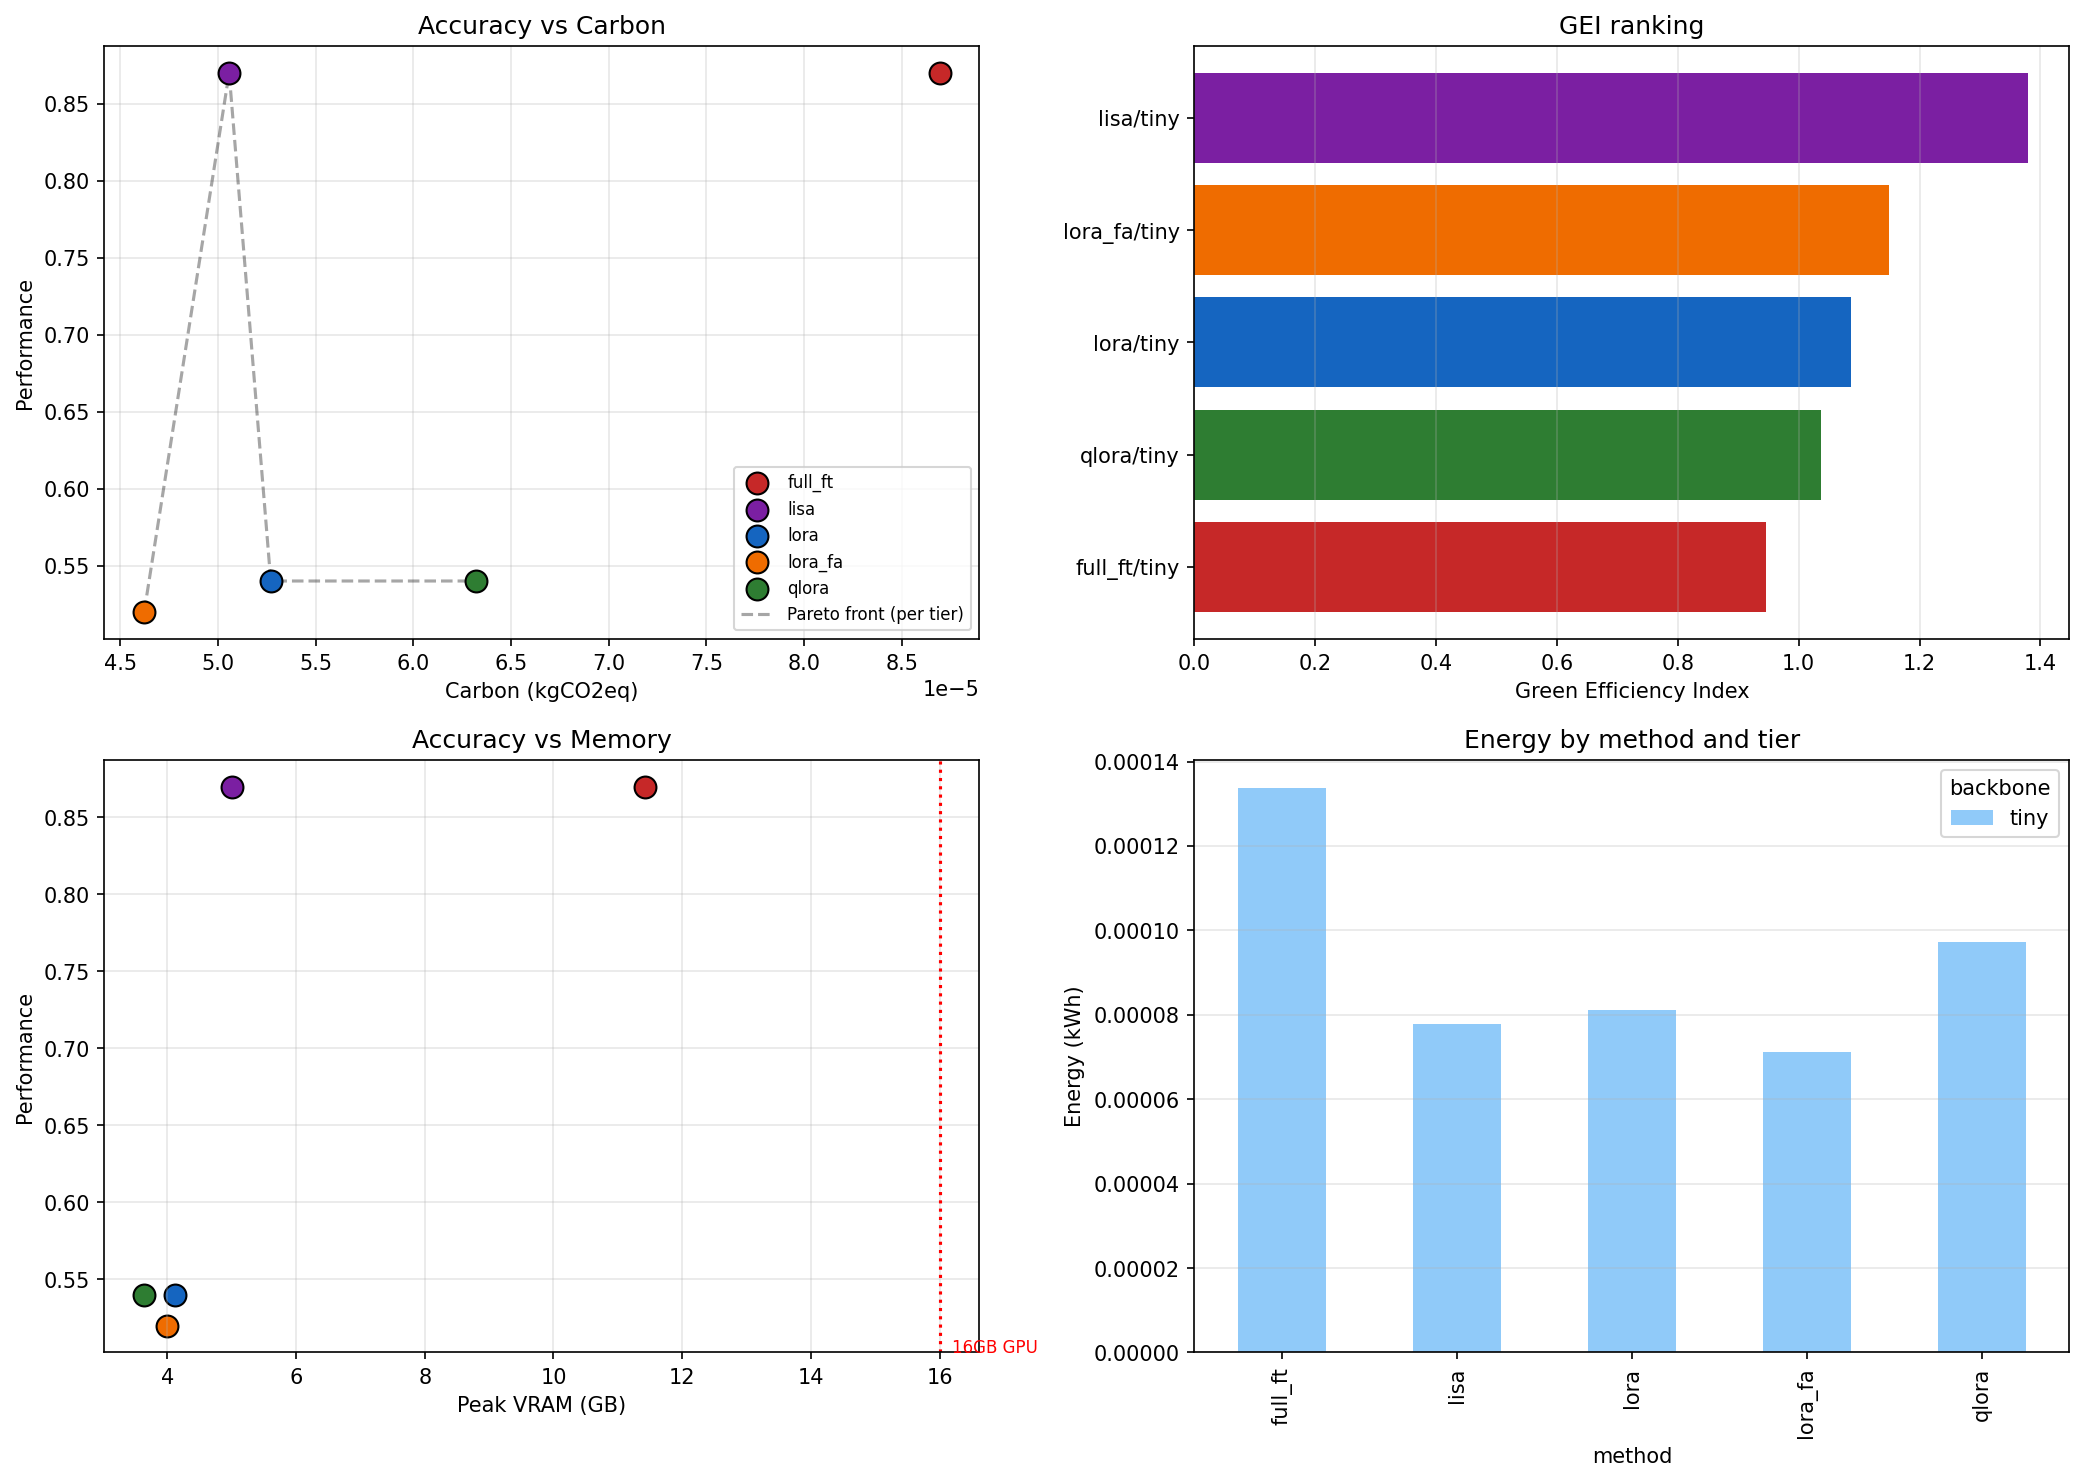

In [15]:
# ==================== CELL 15: Plots ====================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

gei = pd.read_csv(RESULTS_DIR / 'aggregated_gei.csv')
pareto = pd.read_csv(RESULTS_DIR / 'pareto_fronts.csv')
MCOLORS = {'full_ft': '#c62828', 'lora': '#1565c0', 'qlora': '#2e7d32',
           'lora_fa': '#ef6c00', 'lisa': '#7b1fa2'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
for m, blk in gei.groupby('method'):
    ax.scatter(blk['carbon_kgco2eq_mean'], blk['accuracy_mean'], s=110,
               label=m, color=MCOLORS.get(m, 'gray'), edgecolor='k', zorder=3)
for lbl, pf in pareto.groupby('front_label'):
    pf = pf.sort_values('carbon_kgco2eq_mean')
    ax.plot(pf['carbon_kgco2eq_mean'], pf['accuracy_mean'], '--', color='k', alpha=.35)
ax.plot([], [], '--', color='k', alpha=.35, label='Pareto front (per tier)')
ax.set_xlabel('Carbon (kgCO2eq)'); ax.set_ylabel('Performance'); ax.set_title('Accuracy vs Carbon')
ax.legend(fontsize=8); ax.grid(alpha=.3)

ax = axes[0, 1]
o = gei.sort_values('gei', ascending=True)
ax.barh([f'{r.method}/{r.backbone}' for r in o.itertuples()], o['gei'],
        color=[MCOLORS.get(m, 'gray') for m in o['method']])
ax.set_xlabel('Green Efficiency Index'); ax.set_title('GEI ranking'); ax.grid(alpha=.3, axis='x')

ax = axes[1, 0]
for m, blk in gei.groupby('method'):
    ax.scatter(blk['peak_mem_gb_mean'], blk['accuracy_mean'], s=110,
               label=m, color=MCOLORS.get(m, 'gray'), edgecolor='k')
ax.axvline(16, ls=':', color='r'); ax.text(16.2, ax.get_ylim()[0], '16GB GPU', color='r', fontsize=8)
ax.set_xlabel('Peak VRAM (GB)'); ax.set_ylabel('Performance'); ax.set_title('Accuracy vs Memory')
ax.grid(alpha=.3)

ax = axes[1, 1]
piv = gei.pivot_table(index='method', columns='backbone', values='energy_kwh_mean')
piv.plot(kind='bar', ax=ax, color=['#90caf9', '#64b5f6', '#1e88e5', '#0d47a1'][:piv.shape[1]])
ax.set_ylabel('Energy (kWh)'); ax.set_title('Energy by method and tier'); ax.grid(alpha=.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'benchmark_overview.png', dpi=150, bbox_inches='tight')
print('Saved', FIGURES_DIR / 'benchmark_overview.png')

from IPython.display import Image, display as _d
_d(Image(str(FIGURES_DIR / 'benchmark_overview.png')))

In [16]:
# ==================== CELL 16: Export bundle ====================
import shutil

staging = ROOT / 'export_bundle'
if staging.exists():
    shutil.rmtree(staging)
staging.mkdir(parents=True)

for src in [RAW_DIR, FIGURES_DIR, CONFIG_DIR,
            RESULTS_DIR / 'sweep_raw.csv', RESULTS_DIR / 'aggregated.csv',
            RESULTS_DIR / 'aggregated_scored.csv', RESULTS_DIR / 'aggregated_gei.csv',
            RESULTS_DIR / 'pareto_fronts.csv']:
    if src.is_dir():
        shutil.copytree(src, staging / src.name, dirs_exist_ok=True)
    elif src.exists():
        shutil.copy2(src, staging / src.name)

manifest = {
    'generated_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'run_mode': RUN_MODE, 'platform': PLATFORM, 'gpu': GPU_NAME,
    'backbones': BACKBONES, 'methods': METHODS, 'tasks': TASKS, 'seeds': SEEDS,
    'train_steps': TRAIN_STEPS, 'batch_size': BATCH_SIZE,
    'grid_carbon_kg_per_kwh': GRID_CARBON_KG_PER_KWH,
    'gei_weights': GEI_WEIGHTS,
    'n_raw_runs': len(list(RAW_DIR.glob('*.json'))),
}
json.dump(manifest, open(staging / 'manifest.json', 'w'), indent=2)

archive = shutil.make_archive(str(ROOT / 'sustainable_peft_benchmark_bundle'), 'zip', staging)
print('Bundle:', archive)
print('Size  :', round(Path(archive).stat().st_size / 1e6, 2), 'MB')
if IN_KAGGLE:
    shutil.copy2(archive, '/kaggle/working/')
    print('\nCopied to /kaggle/working -> download it from the Output panel on the right.')
elif IN_COLAB:
    from google.colab import files
    print('\nRun files.download(archive) in a new cell to download it.')

Bundle: /kaggle/working/peft_bench/sustainable_peft_benchmark_bundle.zip
Size  : 0.14 MB

Copied to /kaggle/working -> download it from the Output panel on the right.


## Troubleshooting

| Symptom | Fix |
|---|---|
| `ImportError` right after Cell 1 | Session -> Restart, then run Cell 1 again with `INSTALL = False` |
| `CUDA out of memory` on every run | Lower `BATCH_SIZE` to 2 and `MAX_SEQ_LEN` to 128 in Cell 2 |
| QLoRA rows all skipped | Your GPU is a P100. Switch Kaggle accelerator to **GPU T4 x2** |
| Dataset download fails on Kaggle | Notebook Settings -> Internet = **ON** |
| Energy is a flat number every run | NVML is missing, so a fixed TDP was used. Only real on a proper GPU runtime |
| Session died mid-sweep | Just re-run Cell 10. Finished runs are skipped automatically |
| `full_ft` rows say `oom` | Expected on medium/large tiers with 16 GB. It is a result, keep it |

## Kaggle vs Colab

| | Kaggle | Colab Free |
|---|---|---|
| GPU | T4 x2 or P100, 16 GB | T4, 16 GB |
| Session length | 12 h | ~90 min idle cutoff |
| Weekly quota | 30 h | vague, throttled |
| Files survive | Yes, in `/kaggle/working` | No, wiped on disconnect |
| Verdict | **Use this for the real sweep** | Fine for `smoke` only |
